# Практическое занятие №4

## Случайные сигналы, шумы и спектральная плотность мощности

## Задание 1. Генерация белого, розового и красного шума
Сгенерируйте три сигнала длительностью 2 секунды с частотой дискретизации 1000 Гц:
- Белый гауссов шум с нулевым средним и дисперсией 1.
- Розовый шум – возьмите Фурье-преобразование от белого шума, домножьте его на функцию $1/\sqrt{f}$ и возьмите обратное Фурье-преобразование, результат нормализуйте.
- красный шум – кумулятивная сумма белого шума (нормалиованная).

Постройте временные графики всех трёх сигналов. Вычислите и выведите их средние значения и дисперсии.


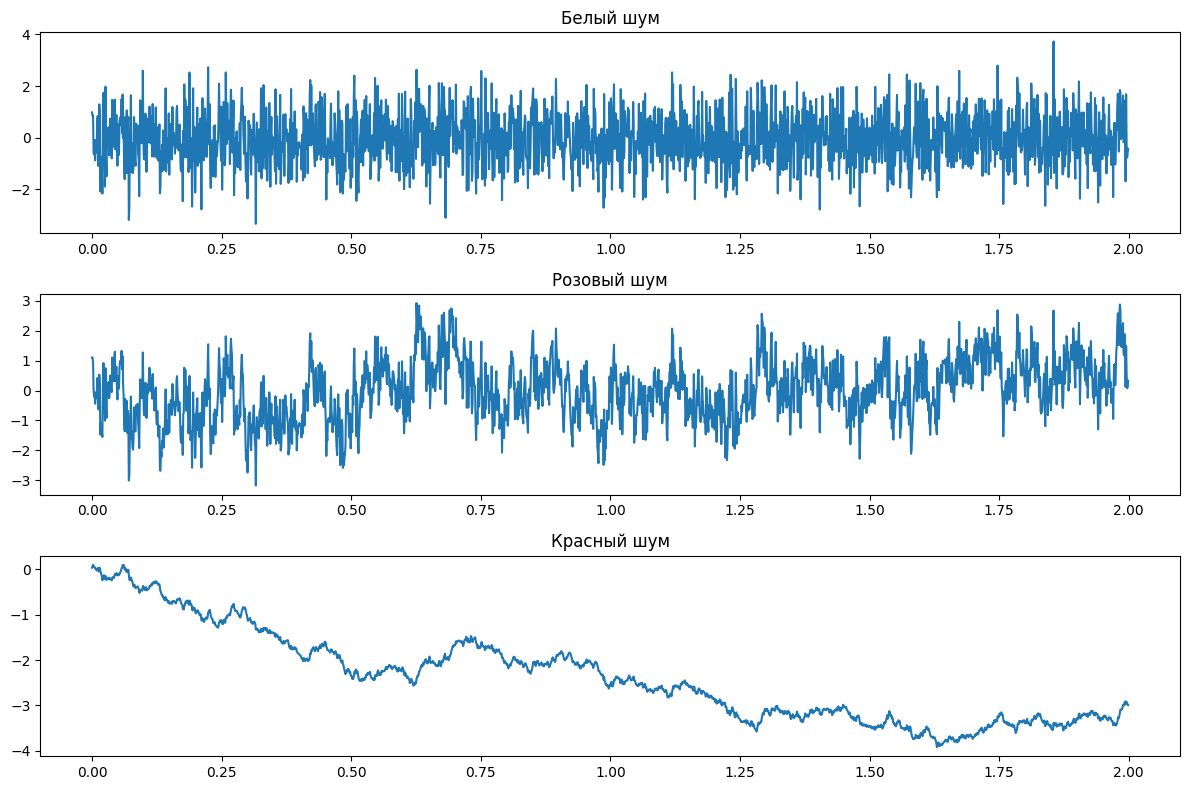

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import ipywidgets as widgets
from IPython.display import display

fs = 1000
T = 2000
t = np.arange(T) / fs

white_noise = np.random.normal(0, 1, T)

w_fft = np.fft.rfft(white_noise)
freqs = np.fft.rfftfreq(T, d=1/fs)

with np.errstate(divide='ignore', invalid='ignore'):
    scaling = 1.0 / np.sqrt(freqs)
scaling[0] = 0

pink_fft = w_fft * scaling
pink_noise = np.fft.irfft(pink_fft, n=T)
pink_noise = pink_noise / np.std(pink_noise)

red_noise = np.cumsum(white_noise)
red_noise = red_noise / np.std(red_noise)

plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
plt.plot(t, white_noise)
plt.title('Белый шум')
plt.subplot(3, 1, 2)
plt.plot(t, pink_noise)
plt.title('Розовый шум')
plt.subplot(3, 1, 3)
plt.plot(t, red_noise)
plt.title('Красный шум')
plt.tight_layout()
plt.show()

**Вопрос:** Как визуально отличаются разные виды шума? Совпадают ли вычисленные средние и дисперсии сигналов от теоретических? Если отличаются, объясните почему.


Белый шум состоит из постоянных скачков, розовый более мягче по сравнению с белым, а краснай самый плавный, так как каждое следующее значение зависит от предыдущего.

## Задание 2. Вычисление автокорреляционной функции (АКФ)
Для каждого из сгенерированных шумов вычислите автокорреляционную функцию (с помощью `np.correlate(x, x, mode='full')`). Возьмите только положительные сдвиги (или сдвиги от -N+1 до N-1, но визуализируйте симметричную часть). Постройте графики нормированных АКФ (поделите на значение при нулевом сдвиге) для всех трёх шумов на одном рисунке.


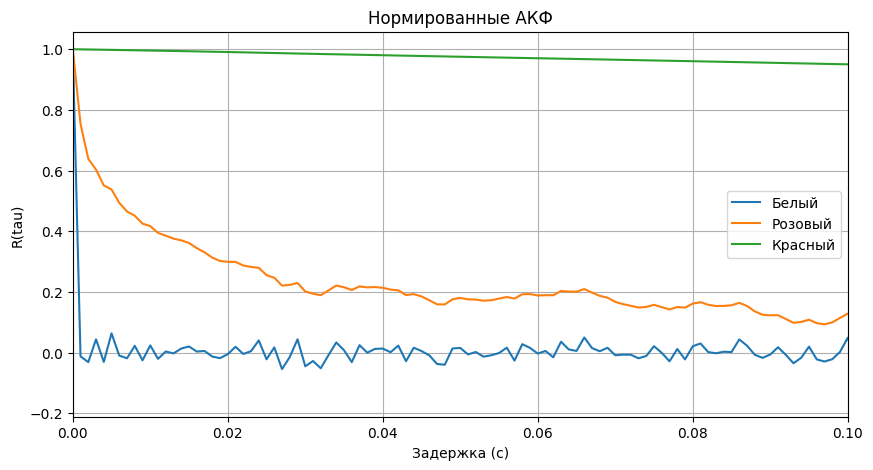

In [ ]:
def calc_acf(x):
    corr = np.correlate(x, x, mode='full')
    acf = corr[corr.size // 2:]
    return acf / acf[0]

plt.figure(figsize=(10, 5))
lags = np.arange(T) / fs
plt.plot(lags, calc_acf(white_noise), label='Белый')
plt.plot(lags, calc_acf(pink_noise), label='Розовый')
plt.plot(lags, calc_acf(red_noise), label='Красный')
plt.title('Нормированные АКФ')
plt.xlabel('Задержка (с)')
plt.ylabel('R(tau)')
plt.xlim(0, 0.1)
plt.legend()
plt.grid(True)
plt.show()

**Вопрос:** Сравнив АКФ и временную развёртку для разных видов шума, сделайте вывод о том, как форма АКФ связана с гладкостью сигнала.


Форма АКФ отражает зависимости соседних отсчетов. У розового и красного шума АКФ затухает медленно, чем шире основание пика АКФ, тем более гладким и коррелированным является сигнал во времени

## Задание 3. Оценка спектральной плотности мощности (СПМ). Периодограмма и метод Уэлча
Для каждого типа шума вычислите:
- Периодограмму с помощью `scipy.signal.periodogram`.
- Оценку СПМ методом Уэлча с помощью `scipy.signal.welch` с параметрами `nperseg=256`, `noverlap=128`, окно Ханна.

Постройте на одном графике (для каждого шума отдельно) периодограмму и оценку Уэлча в двойном логарифмическом масштабе по оси Y (используйте `plt.loglog`).


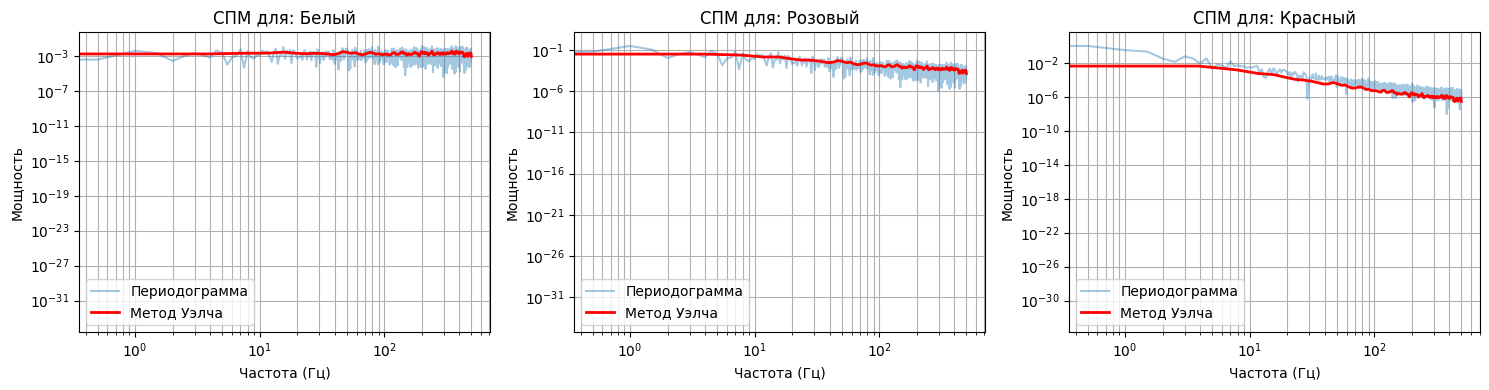

In [ ]:
def plot_psd_compare(sig, name):
    f_per, P_per = signal.periodogram(sig, fs)
    f_wel, P_wel = signal.welch(sig, fs, nperseg=256, noverlap=128)

    plt.loglog(f_per, P_per, alpha=0.4, label='Периодограмма')
    plt.loglog(f_wel, P_wel, 'r', linewidth=2, label='Метод Уэлча')
    plt.title(f'СПМ для: {name}')
    plt.xlabel('Частота (Гц)')
    plt.ylabel('Мощность')
    plt.legend()
    plt.grid(True, which="both")

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1); plot_psd_compare(white_noise, 'Белый')
plt.subplot(1, 3, 2); plot_psd_compare(pink_noise, 'Розовый')
plt.subplot(1, 3, 3); plot_psd_compare(red_noise, 'Красный')
plt.tight_layout()

**Вопрос:** Как выглядят зависимости СПМ от частоты у разных видов шума в двойном логарифмическом масштабе? Как они должны выглядеть теоретически?


{Введите ваш ответ здесь}

## Задание 4. Влияние длины сегмента в методе Уэлча
Для белого шума вычислите оценку СПМ методом Уэлча с разной длиной сегмента: `nperseg = 64, 128, 256, 512`. Используйте окно Ханна, перекрытие 50%. Постройте все четыре оценки на одном графике (логарифмическая шкала по Y).


In [ ]:
# Ваш код здесь

**Вопрос:** Как увеличение длины сегмента влияет на разрешение по частоте (ширину пиков) и гладкость оценки (дисперсию значений)?


{Введите ваш ответ здесь}

## Задание 5. Влияние дисперсии шума на его характеристики
Для каждого вида шума вычислите и выведите на один график при разных значениях дисперсии (например, 0.1, 1, 10):
1. Временную реализацию.
2. АКФ.
3. СПМ.

In [ ]:
# Ваш код здесь

**Вопрос:** Что меняется при изменении дисперсии в каждом случае?


{Введите ваш ответ здесь}

## Задание 6. Обнаружение гармонического сигнала на фоне шума. Спектральный анализ зашумлённой синусоиды
Сгенерируйте сигнал длительностью 2 секунды (fs=1000 Гц), состоящий из:
- синусоиды частотой 110 Гц с амплитудой 1,
- белого гауссова шума с дисперсией, обеспечивающей отношение сигнал/шум (SNR) = 10 дБ.

SNR (дБ) = $10 \log_{10}(P_{signal}/P_{noise})$.

1. Оцените СПМ с помощью метода Уэлча (выберите `nperseg` так, чтобы частота 110 Гц была хорошо разрешена). Определите частоту пика и сравните с истинной.
2. Повторите для других значений SNR ($0$ дБ, $-10$ дБ, $-20$ дБ и т. д.)


In [ ]:
# Ваш код здесь

**Вопрос:** Как меняется видимость пика на спектре при изменении SNR? При каком SNR пик ещё можно уверенно обнаружить визуально?


{Введите ваш ответ здесь}

## Задание 7. Разрешение двух близких частот
Сгенерируйте сигнал, содержащий две синусоиды с частотами 100 и 110 Гц, равными амплитудами 1, и белый шум с дисперсией 0.1. Длительность сигнала 1 секунда, fs=1000 Гц. Используйте метод Уэлча с разными длинами сегмента: 128, 256, 512. Постройте оценки СПМ для каждого случая.


In [ ]:
# Ваш код здесь

**Вопрос:** При какой длине сегмента удаётся разделить две частоты? Сравните с грубой теоретической оценкой частотного разрешения $\Delta f \approx f_s / N_{seg}$.


{Введите ваш ответ здесь}